## No linealidades

* En general el modelo poblacional de multiples variables puede expresarse como:
    
    \begin{equation*}
    y_i = f(x_{1i},x_{2i},\ldots,x_{Ki}) + u_i
    \end{equation*}
    y el supuesto de linealidad implica que $f(x_{1i},x_{2i},\ldots,x_{Ki})=\beta_0+\beta_1x_{1i}+\beta_2x_{2i}+\cdots+\beta_Kx_{Ki}$.

* Hay alguna forma de incluir *no linealidades* entre una o varias de las variables regresoras y la variable dependiente **sin abandonar el supuesto de linealidad**? Miremos un ejemplo:

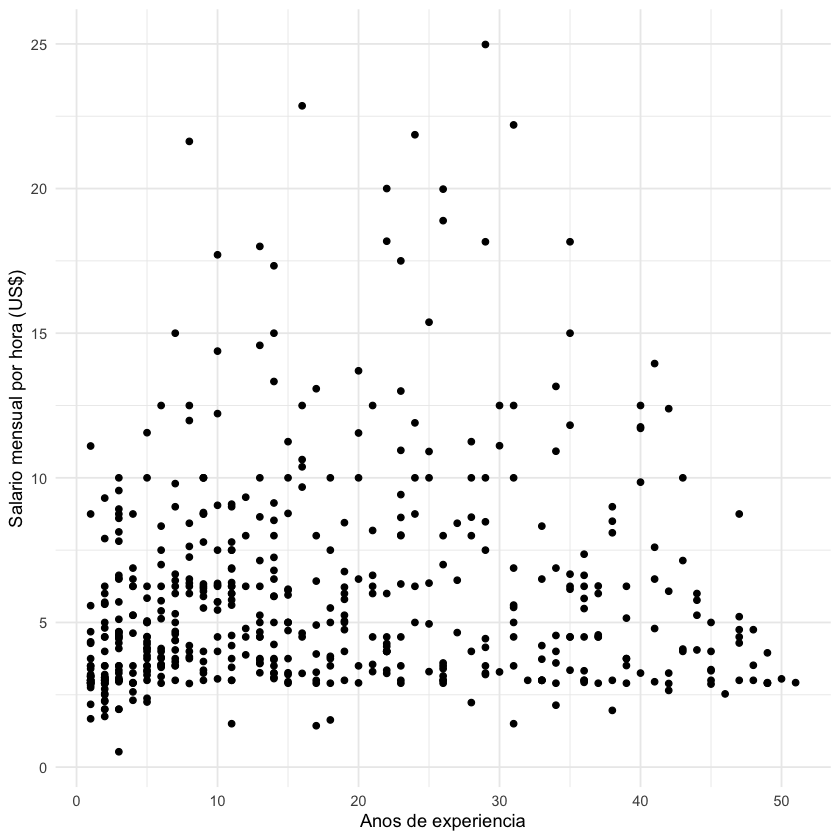

In [4]:
library(wooldridge)
library(tidyverse)
ggplot(wage1, aes(exper,wage)) + 
geom_point() + 
theme_minimal() +
labs(x = 'Anos de experiencia', y = 'Salario mensual por hora (US$)')

### Polinomios
* Una forma de introducir no linealidades es incluir *polinomios*. Por ejemplo, consideremos el siguiente modelo poblacional:
    
    \begin{equation*}
    y_i = \beta_0+\beta_1x_{1i}+\beta_2x_{2i}+\beta_3x_{2i}^2 + \beta_4x_{2i}^3+\cdots+\beta_{r+1}x_{2i}^r + u_i;\;\;\;r>3
    \end{equation*}
    
    Noten que:

    - $\{X_2^2,\ldots,X_2^r\}$ son **transformaciones no lineales de $X_2$**, pero la relación entre estas **nuevas variables** y la variable dependiente sigue siendo lineal!

    - Si $X_{2}$ es una variable aleatoria continua y $E[u_i|X_1,X_2]=0$, entonces el efecto causal de $X_2$ podria medirse como:
        
        \begin{equation*}
        \frac{\partial E[y_i|X_1=x_{1i},X_2]}{\partial x_{2i}} = \beta_2 + 2\beta_3x_{2i} + 3\beta_4x_{2i}^2 + \cdots + r\beta_{r+1}x_{2i}^{r-1}
        \end{equation*}
        
        el cual **no es constante ni necesariamente lineal** en $X_2$!!

    - Consideremos el siguiente modelo poblacional:
        
        \begin{equation*}
        \text{\texttt{wage}}_i = \beta_0 + \beta_1\text{\texttt{educ}}_i + \beta_2\text{\texttt{exper}}_i + \beta_3\text{\texttt{exper}}_i^2 + u_i
        \end{equation*}
        
        Con la muestra *wage1*, estimemos los coeficientes bajo el criterio de MCO:

In [5]:
library(sandwich)
library(AER)
library(stargazer)
# Primero creamos la variable transformada
#wage1$exper_cuad <- wage1$exper^2
wage1 <- wage1 %>%
    mutate(exper_cuad = exper^2)

# Ahora estimamos los coeficientes
regpoly <- lm(wage ~  educ + exper + exper_cuad, data = wage1)
vcovregpoly_rob <- vcovHC(regpoly, type = "HC1")
regpoly_rob <- coeftest(regpoly, vcov. = vcovregpoly_rob)
stargazer(regpoly, regpoly_rob, type = 'text')


                            Dependent variable:        
                    -----------------------------------
                             wage                      
                              OLS           coefficient
                                               test    
                              (1)               (2)    
-------------------------------------------------------
educ                       0.595***          0.595***  
                            (0.053)           (0.062)  
                                                       
exper                      0.268***          0.268***  
                            (0.037)           (0.035)  
                                                       
exper_cuad                 -0.005***         -0.005*** 
                            (0.001)           (0.001)  
                                                       
Constant                   -3.965***         -3.965*** 
                            (0.752)           (

### Transformaciones de las variables

* Nos concentramos en la **transformación logarítmica**. En particular, para cualquier variable continua $X$ es posible decir que:
    
    \begin{equation*}
    \ln{(x+\Delta x) - \ln{(x)}} \approx \frac{\Delta x}{x}
    \end{equation*}
    Si $\frac{\Delta x}{x}\rightarrow 0$.

* A partir de esta aproximación, podemos hablar de las siguientes *clases* de modelos poblacionales (simples):

1. **Modelo lineal - log**:
    
    \begin{equation*}
    \color{orange}y_i = \beta_0 + \beta_1\ln{(x_i)} + u_i
    \end{equation*}
    
    Dado $E[u_i|X]=0$, cuál es el efecto de un cambio en la variable regresora equivalente a $\Delta x_i$?

    - Sin cambio:
        
        \begin{equation*}
        E[y_i|X=x_i] = \beta_0 + \beta_1\ln{(x_i)}
        \end{equation*}

    - Con cambio:
        
        \begin{equation*}
        E[y_i|X=x_i+\Delta x_i] = \beta_0 + \beta_1\ln{(x_i+\Delta x_i)}
        \end{equation*}

    - Ahora evaluemos el **efecto del cambio**:
        
        \begin{align*}
        \underbrace{E[y_i|X=x_i+\Delta x_i] - E[y_i|X=x_i]}_{\color{blue}\approx\Delta E[y_i|X]} &= (\beta_0 + \beta_1\ln{(x_i+\Delta x_i)}) - (\beta_0 + \beta_1\ln{(x_i)})\\[0.2cm]
        &= \beta_1(\underbrace{\ln{(x_i+\Delta x_i)}-\ln{(x_i)}}_{\color{blue}\approx\frac{\Delta x_i}{x_i}})\\[0.2cm]        
        \color{blue}\Delta E[y_i|X]&\color{blue}\approx\beta_1\frac{\Delta x_i}{x_i}
        \end{align*}
        
        por lo tanto:
        
        \begin{equation*}            
        \color{red}\frac{\Delta E[y_i|X]}{\Delta x_i} \approx \beta_1\frac{1}{x_i}
        \end{equation*}
        
        o...
        
        \begin{equation*}
        \color{red}\beta_1  \approx \frac{\Delta E[y_i|X]}{\frac{\Delta x_i}{x_i}}
        \end{equation*}
        
        $\beta_1$ representa entonces el **cambio en el valor medio condicionado de $Y$ ante un incremento porcentual unitario de $X$**. Miremos un ejemplo. Asumamos que nuestro modelo poblacional es:
        
        \begin{equation*}
        \text{\texttt{bwghtlbs}}_i = \beta_0 + \beta_1\text{\texttt{packs}}_i + \beta_2\text{\texttt{motheduc}}_i + \beta_3\ln{(\text{\texttt{faminc}}_i)} + u_i
        \end{equation*}
        
        Estimemos los coeficientes con la muestra *bwght*:

In [6]:
# Primero creamos la variable a partir de la transformación ln():
#bwght$log_faminc <- log(bwght$faminc)
bwght <- bwght %>%
    mutate(log_faminc = log(faminc))
# Ahora estimamos los coeficientes:
reglinlog <- lm(bwghtlbs ~  packs + motheduc + log_faminc, data = bwght)
vcovreglinlog_rob <- vcovHC(reglinlog, type = "HC1")
reglinlog_rob <- coeftest(reglinlog, vcov. = vcovreglinlog_rob)
stargazer(reglinlog, reglinlog_rob, type = 'text')


                            Dependent variable:         
                    ------------------------------------
                            bwghtlbs                    
                              OLS            coefficient
                                                test    
                              (1)                (2)    
--------------------------------------------------------
packs                      -0.581***          -0.581*** 
                            (0.116)            (0.113)  
                                                        
motheduc                     0.004              0.004   
                            (0.016)            (0.015)  
                                                        
log_faminc                  0.111***          0.111***  
                            (0.040)            (0.040)  
                                                        
Constant                    7.091***          7.091***  
                            (0

Si asumimos que $\beta_3$ representa el efecto causal del cambio en el ingreso familiar sobre el peso del infante, entonces $\hat{\beta}_3 = 0.111$ llevaría a la siguiente interpretación: *se estima que el valor medio del peso al nacer del infante se incrementa en 0.11 libras ante un incremento del 1% en el ingreso familiar*.

2. **Modelo log-lineal**:
    
    \begin{equation*}
    \color{orange}\ln{(y_i)} = \beta_0 + \beta_1x_i + u_i
    \end{equation*}
    
    Dado $E[u_i|X]=0$, cuál es el efecto de un cambio en la variable regresora equivalente a $\Delta x_i$?

    - Sin cambio:
        
        \begin{equation*}
        E[\ln{(y_i)}|X=x_i] = \beta_0 + \beta_1x_i
        \end{equation*}

    - Con cambio:
        
        \begin{equation*}
        E[\ln{(y_i)}|X=x_i+\Delta x_i] = \beta_0 + \beta_1(x_i+\Delta x_i)
        \end{equation*}

    - Ahora evaluemos el **efecto del cambio**:
        
        \begin{align*}
        \underbrace{E[\ln{(y_i)}|X=x_i+\Delta x_i] - E[\ln{(y_i)}|X=x_i]}_{\color{blue}\approx\frac{\Delta E[y_i|X]}{E[y_i|X]}} &= (\beta_0 + \beta_1(x_i+\Delta x_i) - (\beta_0 + \beta_1x_i)\\[0.2cm]
        &= \beta_1\Delta x_i\\[0.2cm]        
        \color{blue}\frac{\Delta E[y_i|X]}{E[y_i|X]}&\color{blue}\approx\beta_1\Delta x_i
        \end{align*}

        por lo tanto:
        
        \begin{equation*}            
        \color{red}\frac{\Delta E[y_i|X]}{\Delta x_i} \approx \beta_1E[y_i|X]
        \end{equation*}
        
        o...
        
        \begin{equation*}
        \color{red}\beta_1  \approx \frac{\frac{\Delta E[y_i|X]}{E[y_i|X]}}{\Delta x_i}
        \end{equation*}
        
        $\beta_1$ representa entonces el **cambio porcentual del valor medio condicionado de $Y$** ante un **incremento unitario de $X$**. Miremos otro ejemplo. Esta vez asumamos que el modelo poblacional es:
        
        \begin{equation*}
        \ln{(\text{\texttt{wage}}_i)} = \beta_0 + \beta_1\text{\texttt{educ}}_i + \beta_2{\color{orange}\text{\texttt{IQ}}_i} + \beta_3{\color{orange}\text{\texttt{exper}}_i} + \beta_3{\color{orange}\text{\texttt{exper}}_i^2} + u_i
        \end{equation*}
        
        Estimemos los coeficientes con la muestra *wage2*:

In [7]:
# Primero creamos la variable a partir de la transformación ln():
#wage2$log_wage <- log(wage2$wage)
wage2 <- wage2 %>%
    mutate(log_wage = log(wage), exper_cuad = exper^2)

# Ahora estimamos los coeficientes:
regloglin <- lm(log_wage ~  educ + IQ + exper + exper_cuad, data = wage2)
vcovregloglin_rob <- vcovHC(regloglin, type = "HC1")
regloglin_rob <- coeftest(regloglin, vcov. = vcovregloglin_rob)
stargazer(regloglin, regloglin_rob, type = 'text')


                            Dependent variable:        
                    -----------------------------------
                           log_wage                    
                              OLS           coefficient
                                               test    
                              (1)               (2)    
-------------------------------------------------------
educ                       0.057***          0.057***  
                            (0.007)           (0.008)  
                                                       
IQ                         0.006***          0.006***  
                            (0.001)           (0.001)  
                                                       
exper                        0.016             0.016   
                            (0.013)           (0.014)  
                                                       
exper_cuad                  0.0002            0.0002   
                            (0.001)           (

En este caso, si asumimos que $\beta_1$ representa el efecto causal de $\texttt{educ}$ sobre $\texttt{wage}$, el valor estimado $\hat{\beta}_1=0.057$ llevaría a la siguiente interpretación: *un adicional de educación incrementaría el salario mensual del individuo en aproximadamente el 6%*. 

3. **Modelo log-log**:
    
    \begin{equation*}
    \color{orange}\ln{(y_i)} = \beta_0 + \beta_1\ln{(x_i)} + u_i
    \end{equation*}
    
    Dado $E[u_i|X]=0$, cuál es el efecto de un cambio en la variable regresora equivalente a $\Delta x_i$?

    - Sin cambio:
        
        \begin{equation*}
        E[\ln{(y_i)}|X=x_i] = \beta_0 + \beta_1\ln{(x_i)}
        \end{equation*}

    - Con cambio:
        
        \begin{equation*}
        E[\ln{(y_i)}|X=x_i+\Delta x_i] = \beta_0 + \beta_1\ln{(x_i+\Delta x_i)}
        \end{equation*}

    - Ahora evaluemos el **efecto del cambio**:
        
        \begin{align*}
        \underbrace{E[\ln{(y_i)}|X=x_i+\Delta x_i] - E[\ln{(y_i)}|X=x_i]}_{\color{blue}\approx\frac{\Delta E[y_i|X]}{E[y_i|X]}} &= (\beta_0 + \beta_1\ln{(x_i+\Delta x_i)}) - (\beta_0 + \beta_1\ln{(x_i)})\\[0.2cm]
        &= \beta_1(\underbrace{\ln{(x_i+\Delta x_i)}-\ln{(x_i)}}_{\color{blue}\approx\frac{\Delta x_i}{x_i}})\\[0.2cm]        
        \color{blue}\frac{\Delta E[y_i|X]}{E[y_i|X]}&\color{blue}\approx\beta_1\frac{\Delta x_i}{x_i}
        \end{align*} 
        
        por lo tanto:
        
        \begin{equation*}            
        \color{red}\frac{\Delta E[y_i|X]}{\Delta x_i} \approx \beta_1\frac{\Delta x_i}{x_i}
        \end{equation*}
        
        o...
        
        \begin{equation*}
        \color{red}\beta_1  \approx \frac{\frac{\Delta E[y_i|X]}{E[y_i|X]}}{\frac{\Delta x_i}{x_i}} = \frac{x_i}{E[y_i|X]}\frac{\Delta E[y_i|X]}{\Delta x_i}
        \end{equation*}
        
        $\beta_1$ representa entonces el **cambio porcentual del valor medio condicionado de $Y$** ante un **incremento porcental unitario de $X$**$\Rightarrow$ **Elasticidad de $Y$ con respecto a $X$**. Retomemos el modelo de peso al nacer, pero ahora con un pequeño cambio en el modelo poblacional:
        
        \begin{equation*}
        \ln{(\text{\texttt{bwghtlbs}}_i)} = \beta_0 + \beta_1\text{\texttt{packs}}_i + \beta_2\text{\texttt{motheduc}}_i + \beta_3\ln{(\text{\texttt{faminc}}_i)} + u_i
        \end{equation*}
        
        Estimemos de nuevo los coeficientes con la muestra *bwght*:    
    
    

In [9]:
# Primero creamos la variable dependiente a partir de la transformación ln():
#bwght$log_bwghtlbs <- log(bwght$bwghtlbs)
bwght <- bwght %>%
    mutate(log_bwghtlbs = log(bwghtlbs))

# Ahora estimamos los coeficientes:
regloglog <- lm(log_bwghtlbs ~  packs + motheduc + log_faminc, data = bwght)
vcovregloglog_rob <- vcovHC(regloglog, type = "HC1")
regloglog_rob <- coeftest(regloglog, vcov. = vcovregloglog_rob)
stargazer(regloglog, regloglog_rob, type = 'text')


                            Dependent variable:         
                    ------------------------------------
                          log_bwghtlbs                  
                              OLS            coefficient
                                                test    
                              (1)                (2)    
--------------------------------------------------------
packs                      -0.081***          -0.081*** 
                            (0.017)            (0.017)  
                                                        
motheduc                     0.0005            0.0005   
                            (0.002)            (0.002)  
                                                        
log_faminc                  0.016***          0.016***  
                            (0.006)            (0.006)  
                                                        
Constant                    1.942***          1.942***  
                            (0

Asumiendo que $\beta_3$ representa el efecto causal de un cambio en el ingreso familiar sobre el incremento del peso del recién nacido, el valor estimado $\hat{\beta}_3 = 0.016$, llevería a la siguiente interpretación: *se estima que en promedio, ante un incremento del 1% en el ingreso familiar, el peso del recien nacido se incrementaría en un 1.6%*.

## Interacciones

Ahora supongamos que de forma general nuestro modelo poblacional mide la dependencia entre una variable aleatoria dependiente $Y$, una variable aleatoria $X$ y una variable indicadora o *dummy* $D$ que toma únicamente los valores discretos $\{0,1\}$.

1. **El modelo más simple**:
    
    \begin{equation*}
    y_i = \beta_0 + \beta_1x_i + \beta_2D_i + u_i
    \end{equation*}
    
    Bajo $E[u_i|X,D]=0$ y tomando como base el análisis que hicimos en el caso del modelo simple:
    
    \begin{align*}
    \color{brown}E[y_i|X=x_i,D_i = 0] &\color{brown}= \beta_0 + \beta_1x_i\\[0.2cm]
    E[y_i|X=x_i,D_i = 1] &= \beta_0 + \beta_1x_i + \beta_2 = \underbrace{(\beta_0 + \beta_2)}_{\equiv\tilde{\beta}_0} + \beta_1x_i\\[0.2cm]
    \color{blue}E[y_i|X=x_i,D_i = 1] &\color{blue}= \tilde{\beta}_0 + \beta_1x_i
    \end{align*}
    
    donde $\color{red}\beta_0\neq\tilde{\beta}_0$: **Cambio de intercepto pero no de pendiente**!! Supongamos que el modelo poblacional es:
    
    \begin{equation*}
    \text{\texttt{wage}}_i = \beta_0 + \beta_1\text{\texttt{educ}}_i + \beta_2\text{\texttt{female}}_i + u_i
    \end{equation*}
    
    Con la muestra *wage1*, estimemos los coeficientes bajo el criterio de MCO:    

In [10]:
regintnopen <- lm(wage ~ educ + female, data = wage1)
vcovregintnopen_rob <- vcovHC(regintnopen, type = "HC1")
regintnopen_rob <- coeftest(regintnopen, vcov. = vcovregintnopen_rob)
b_0 <- coefficients(regintnopen)[1]
b_0_tilde <- coefficients(regintnopen)[1]+coefficients(regintnopen)[3]
b_1 <- coefficients(regintnopen)[2]

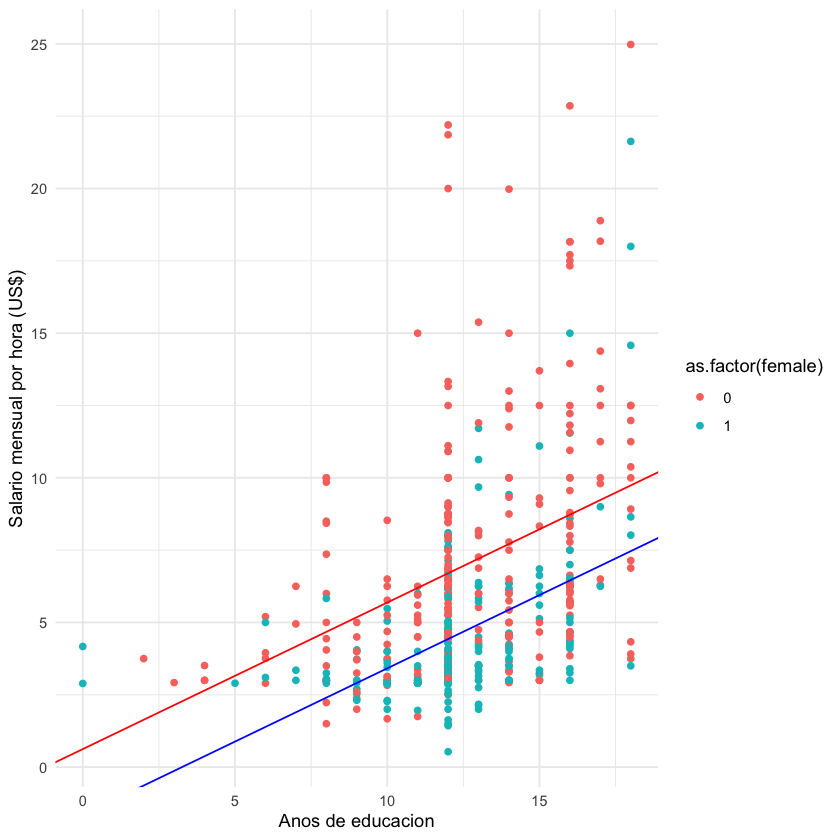

In [11]:
ggplot(wage1, aes(educ, wage, color = as.factor(female))) + 
geom_point() + 
geom_abline(intercept = b_0, slope = b_1, color = "red") +
geom_abline(intercept = b_0_tilde, slope = b_1, color = "blue") +
theme_minimal() +
labs(x = 'Anos de educacion', y = 'Salario mensual por hora (US$)')

2. **Efecto sobre pendiente únicamente**:
    
    En este caso el modelo poblacional considera que la variable $D$ solo afecta a la variable dependiente a través de su interacción con la variable regresora, es decir:
    
    \begin{equation*}
    y_i = \beta_0 + \beta_1x_i + \beta_2(D_i\times x_{i}) + u_i
    \end{equation*}
    
    Asumiendo que $E[u_i|X]=0$, podemos decir que:
    
    \begin{align*}
    \color{brown}E[y_i|X=x_i,D_i = 0] &\color{brown}= \beta_0 + \beta_1x_i\\[0.2cm]
    E[y_i|X=x_i,D_i = 1] &= \beta_0 + \beta_1x_i + \beta_2x_{i} = \beta_0 + \underbrace{(\beta_1 + \beta_2)}_{\equiv\tilde{\beta}_1}x_i\\[0.2cm]
    \color{blue}E[y_i|X=x_i,D_i = 1] &\color{blue}= \beta_0 + \tilde{\beta}_1x_i
    \end{align*}
    
    donde $\color{red}\beta_1\neq\tilde{\beta}_1$: **Cambio de pendiente**!! Por lo tanto:
    
    \begin{align*}
    \color{red}\frac{\partial E[y_i|X,D_i = 0]}{\partial x_i} &\color{red}= \beta_1\\[0.3cm]
    \color{red}\frac{\partial E[y_i|X,D_i = 1]}{\partial x_i} &\color{red}= \beta_1 + \beta_2\equiv\tilde{\beta}_1\\[0.3cm]
    \color{red}\Delta E[y_i|X=x_i,D] &\color{red}= (\tilde{\beta}_1-\beta_1)x_i = \beta_2x_i
    \end{align*}
    
    Supongamos ahora que nuestro modelo poblacional es:
    
    \begin{equation*}
    \text{\texttt{wage}}_i = \beta_0 + \beta_1\text{\texttt{educ}}_i + \beta_2(\text{\texttt{female}}_i\times\text{\texttt{educ}}_i) + u_i
    \end{equation*}
    
    Con la muestra *wage1*, estimemos los coeficientes bajo el criterio de MCO: 

In [12]:
# Creemos primero nuestra variable de interacción:
#wage1$femeduc <- wage1$female * wage1$educ
wage1 <- wage1 %>%
    mutate(femeduc = female*educ)
    
# Ahora estimamos los coeficientes
regnointpen <- lm(wage ~ educ + femeduc, data = wage1)
vcovregnointpen_rob <- vcovHC(regnointpen, type = "HC1")
regnointpen_rob <- coeftest(regnointpen, vcov. = vcovregnointpen_rob)
regnointpen
b_0 <- coefficients(regnointpen)[1]
b_1 <- coefficients(regnointpen)[2]
b_1_tilde <- coefficients(regnointpen)[2] + coefficients(regnointpen)[3]


Call:
lm(formula = wage ~ educ + femeduc, data = wage1)

Coefficients:
(Intercept)         educ      femeduc  
    -0.2853       0.5755      -0.1776  


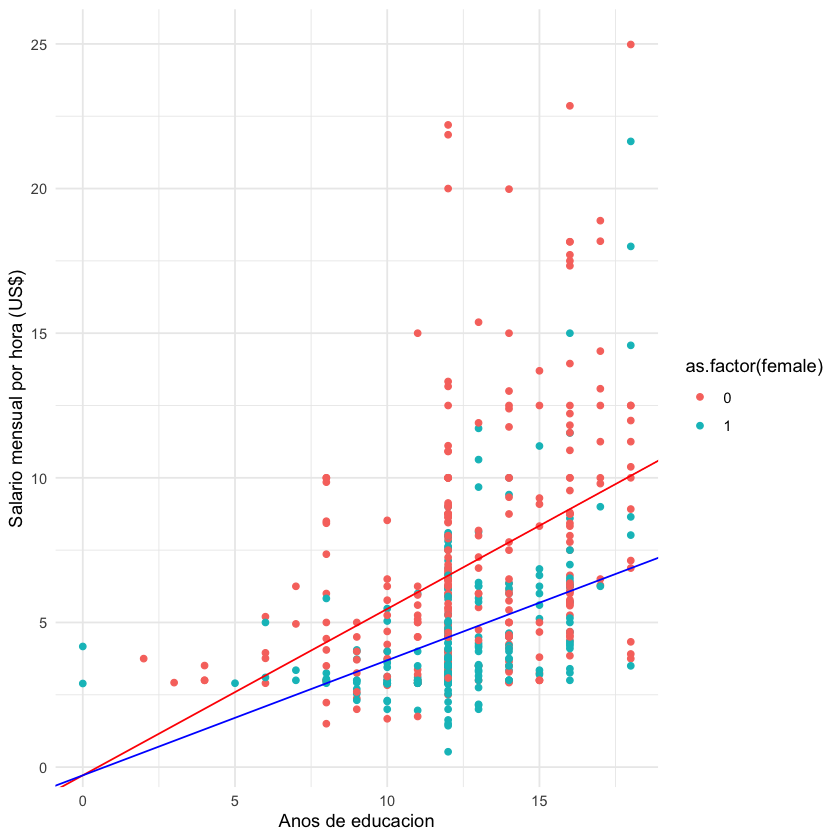

In [13]:
ggplot(wage1, aes(educ, wage, color = as.factor(female))) + 
geom_point() + 
geom_abline(intercept = b_0, slope = b_1, color = "red") +
geom_abline(intercept = b_0, slope = b_1_tilde, color = "blue") +
theme_minimal() +
labs(x = 'Anos de educacion', y = 'Salario mensual por hora (US$)')

3. **Efecto sobre intercepto y pendiente**: En este caso el modelo poblacional considera que la variable $D$ afecta a la variable dependiente por si misma y a través de su interacción con la variable regresora, es decir:
    
    \begin{equation*}
    y_i = \beta_0 + \beta_1x_i + \beta_2D_i + \beta_3(D_i\times x_{i}) + u_i
    \end{equation*}
    
    Asumiendo que $E[u_i|X]=0$, podemos decir que:
    
    \begin{align*}
    \color{brown}E[y_i|X=x_i,D_i = 0] &\color{brown}= \beta_0 + \beta_1x_i\\[0.2cm]
    E[y_i|X=x_i,D_i = 1] &= \beta_0 + \beta_1x_i + \beta_2 + \beta_3x_i = \underbrace{(\beta_0 + \beta_2)}_{\equiv\tilde{\beta}_0} + \underbrace{(\beta_1 + \beta_3)}_{\equiv\tilde{\beta}_1}x_i\\[0.2cm]
    \color{blue}E[y_i|X=x_i,D_i = 1] &\color{blue}= \tilde{\beta_0} + \tilde{\beta}_1x_i
    \end{align*}
    
    donde $\color{red}\beta_0\neq\tilde{\beta}_0$ y $\color{red}\beta_1\neq\tilde{\beta}_1$: **Cambio de intercepto y pendiente**!! Por lo tanto:
    
    \begin{align*}
    \color{red}\frac{\partial E[y_i|X,D_i = 0]}{\partial x_i} &\color{red}= \beta_1\\[0.3cm]
    \color{red}\frac{\partial E[y_i|X,D_i = 1]}{\partial x_i} &\color{red}= \beta_1 + \beta_3\equiv\tilde{\beta}_1\\[0.3cm]
    \color{red}\Delta E[y_i|X=x_i,D] &\color{red}= (\tilde{\beta}_0-\beta_0) + (\tilde{\beta}_1-\beta_1)x_i = \beta_2 + \beta_3x_i
    \end{align*}
    
    Finalmente supongamos que nuestro modelo poblacional es:
    
    \begin{equation*}
    \text{\texttt{wage}}_i = \beta_0 + \beta_1\text{\texttt{educ}}_i + \beta_2\text{\texttt{female}}_i + \beta_3(\text{\texttt{female}}_i\times\text{\texttt{educ}}_i) + u_i
    \end{equation*}
    
    Con la muestra *wage1*, estimemos los coeficientes bajo el criterio de MCO: 

In [14]:
regintpen <- lm(wage ~ educ + female + femeduc, data = wage1)
vcovregintpen_rob <- vcovHC(regintpen, type = "HC1")
regintpen_rob <- coeftest(regintpen, vcov. = vcovregintpen_rob)
regintpen
b_0 <- coefficients(regintpen)[1]
b_0_tilde <- coefficients(regintpen)[1] + coefficients(regintpen)[3] 
b_1 <- coefficients(regintpen)[2]
b_1_tilde <- coefficients(regintpen)[2] + coefficients(regintpen)[4]


Call:
lm(formula = wage ~ educ + female + femeduc, data = wage1)

Coefficients:
(Intercept)         educ       female      femeduc  
     0.2005       0.5395      -1.1985      -0.0860  


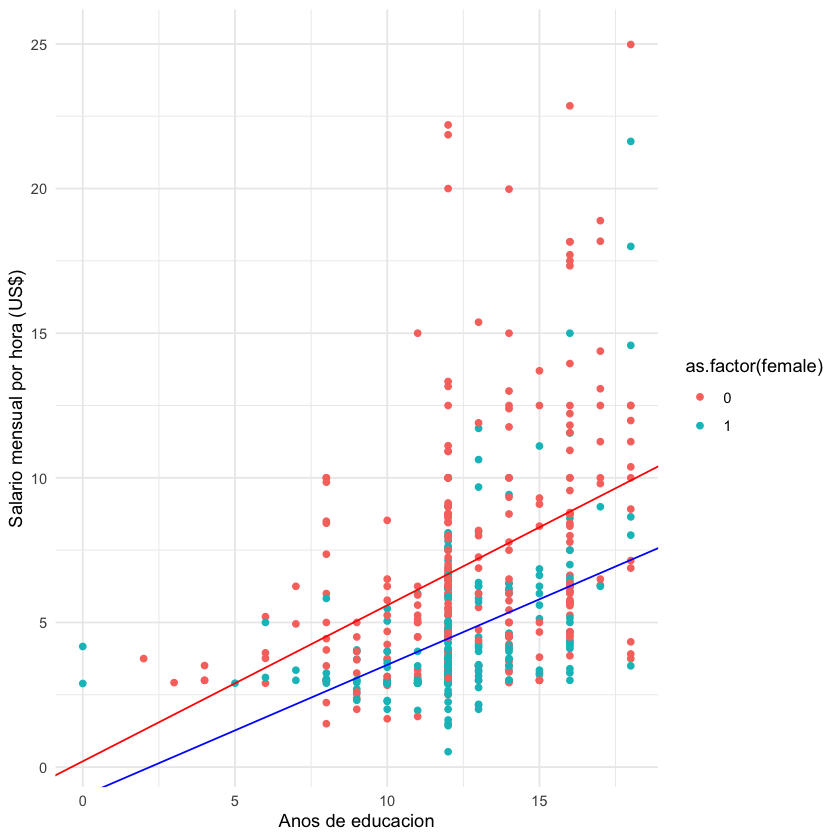

In [15]:
ggplot(wage1, aes(educ, wage, color = as.factor(female))) + 
geom_point() + 
geom_abline(intercept = b_0, slope = b_1, color = "red") +
geom_abline(intercept = b_0_tilde, slope = b_1_tilde, color = "blue") +
theme_minimal() +
labs(x = 'Anos de educacion', y = 'Salario mensual por hora (US$)')

Resumamos todos los modelos:

In [16]:
stargazer(regintnopen_rob, regnointpen_rob, regintpen_rob, type = "text")


              Dependent variable:     
         -----------------------------
                                      
            (1)        (2)      (3)   
--------------------------------------
educ      0.506***  0.575***  0.539***
          (0.060)    (0.059)  (0.073) 
                                      
female   -2.273***             -1.199 
          (0.270)             (1.461) 
                                      
femeduc             -0.178***  -0.086 
                     (0.024)  (0.124) 
                                      
Constant   0.623     -0.285    0.200  
          (0.729)    (0.695)  (0.872) 
                                      
Note:      *p<0.1; **p<0.05; ***p<0.01
